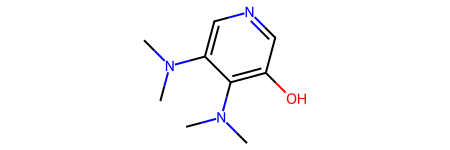

In [9]:
from rdkit import Chem
from rdkit import DataStructs
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
from rdkit.Chem import rdFMCS
from rdkit.Chem.Draw import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdFingerprintGenerator
import cairosvg
import io
import math


import pickle
import matplotlib.pyplot as plt
# import torch
import numpy as np
# from dqn import MolDQN
from rdkit.Chem import QED
# from beautifultable import BeautifulTable, BTRowCollection
# from prettytable import PrettyTable
from rdkit.Chem import Descriptors


import pandas as pd
import pickle
# import joblib
# from molbert.utils.featurizer.molbert_featurizer import MolBertFeaturizer

from rdkit import RDConfig
import numpy as np
import os
import sys
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

from rdkit.DataManip.Metric import GetTanimotoDistMat
from rdkit.DataManip.Metric import GetTanimotoSimMat

IPythonConsole.ipython_useSVG=True
import random

def penalized_logP(mol):
    """
    Logarithm of partition coefficient, penalized by cycle length and synthetic accessibility.

        
    The code are from torchdrug torchdrug/metrics/metric.py
    https://github.com/DeepGraphLearning/torchdrug/blob/6066fbd82360abb5f270cba1eca560af01b8cc90/torchdrug/metrics/metric.py#L84
    
    This version also supports smiles string and should return the exactly same plogp values as torchdrug.

    Parameters:
        # pred (PackedMolecule): molecules to evaluate
        smiles_list: smiles strings to evaluate


    """
    # statistics from ZINC250k
    logp_mean = 2.4570953396190123
    logp_std = 1.434324401111988
    sa_mean = 3.0525811293166134
    sa_std = 0.8335207024513095
    cycle_mean = 0.0485696876403053
    cycle_std = 0.2860212110245455

    # mol = Chem.MolFromSmiles(smiles)
    try:
        mol.UpdatePropertyCache()
        cycles = Chem.GetSymmSSSR(mol)
        if cycles:
            max_cycle = max([len(cycle) for cycle in cycles])
            cycle = max(0, max_cycle - 6)
        else:
            cycle = 0
        logp = Descriptors.MolLogP(mol)
        sa = sascorer.calculateScore(mol)
        logp = (logp - logp_mean) / logp_std
        sa = (sa - sa_mean) / sa_std
        cycle = (cycle - cycle_mean) / cycle_std
        score = logp - sa - cycle
    except Chem.AtomValenceException:
        score = -30
    return score

def mol_to_png(mol, file_name, h = None, l = '', width=300, height=200):
    full_path = f'./Results/path/{file_name}.png'
    # Render high resolution molecule
    drawer = rdMolDraw2D.MolDraw2DSVG(width, height)
    drawer.DrawMolecule(mol, highlightAtoms=h, legend=l)
    drawer.FinishDrawing()

    # Export to pdf
    cairosvg.svg2png(bytestring=drawer.GetDrawingText().encode(), write_to=full_path)

def draw_with_diff(mol1, mol2, file_name, l = ''):
    mcs = rdFMCS.FindMCS([mol1,mol2])
    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
    
    if mol1.GetNumAtoms() <= mol2.GetNumAtoms():
        
        match2 = mol2.GetSubstructMatch(mcs_mol)
        target_atm2 = []
        for atom in mol2.GetAtoms():
            if atom.GetIdx() not in match2:
                target_atm2.append(atom.GetIdx())
        mol_to_png(mol2, file_name, target_atm2, l)
    else:
        match1 = mol1.GetSubstructMatch(mcs_mol)
        r = Chem.RWMol(mol1)
        r.BeginBatchEdit()
        for atom in mol1.GetAtoms():
            if atom.GetIdx() in match1:
                r.RemoveAtom(atom.GetIdx())
        r.CommitBatchEdit()
        rs = Chem.MolToSmiles(r)
        m2s = Chem.MolToSmiles(mol2)
        ns = f'{m2s}.{rs}'
        nm = Chem.MolFromSmiles(ns)
        
        mcs2 = rdFMCS.FindMCS([nm,mol2])
        mcs_mol2 = Chem.MolFromSmarts(mcs2.smartsString)
        match3 = nm.GetSubstructMatch(mcs_mol2)
        target_atmn = []
        for atom in nm.GetAtoms():
            if atom.GetIdx() not in match3:
                target_atmn.append(atom.GetIdx())
        mol_to_png(nm, file_name, target_atmn, l)

Chem.MolFromSmiles('CN(C)c1cncc(O)c1N(C)C')

In [4]:
mols = []
with open('Data/chembl_31_10k.txt', 'r') as f:
# with open('Data/anti_400.txt', 'r') as f:
    ss = f.read().splitlines()
    for s in ss:
        mols.append(Chem.MolFromSmiles(s))

fpg = rdFingerprintGenerator.GetMorganGenerator(fpSize=2048, radius=3)
fps = [fpg.GetFingerprint(mol) for mol in mols]
# fps = [Chem.RDKFingerprint(mol) for mol in mols]

qeds = [QED.qed(mol) for mol in mols]
sas = [sascorer.calculateScore(mol) for mol in mols]
plogps = [penalized_logP(mol) for mol in mols]
num_rings = [len(Chem.GetSymmSSSR(mol)) for mol in mols]

sims = []
qed_sims = []
sas_sims = []
plogps_sims = []
num_rings_sims = []
js, ks = [], []
# for i in range(1000):
#     j = random.randint(0, len(mols) - 1)
#     k = random.randint(0, len(mols) - 1)
#     while k == j:
#         k = random.randint(0, len(mols) - 1)
#     sim = DataStructs.FingerprintSimilarity(fps[j], fps[k])
#     qed_diff = abs(qeds[j] - qeds[k])
#     sa_diff = abs(sas[j] - sas[k])
#     plogp_diff = abs(plogps[j] - plogps[k])
#     num_ring_diff = abs(num_rings[j] - num_rings[k])
    
#     sims.append(sim)
#     qed_sims.append(qed_diff)
#     sas_sims.append(sa_diff)
#     plogps_sims.append(plogp_diff)
#     num_rings_sims.append(num_ring_diff)
#     js.append(j)
#     ks.append(k)

print('done')

done


In [ ]:
pred_g = plt.scatter(sims, qed_sims, color='red', s = 2)
plt.xlabel('Similarity')
plt.ylabel('QED Difference')

In [ ]:
pred_sa = plt.scatter(sims, sas_sims, color='red', s = 2)
plt.xlabel('Similarity')
plt.ylabel('SA Score Difference')

In [ ]:
pred_sa = plt.scatter(sims, plogps_sims, color='red', s = 2)
plt.xlabel('Similarity')
plt.ylabel('PlogP Difference')

In [ ]:
rho = np.corrcoef(sims, qed_sims)
print(rho)
rho = np.corrcoef(sims, sas_sims)
print(rho)
rho = np.corrcoef(sims, plogps_sims)
print(rho)
rho = np.corrcoef(sims, num_rings_sims)
print(rho)

In [100]:
# zinc 250k 
df = pd.read_csv('./Data/250k_rndm_zinc_drugs_clean_3.csv', sep=',')

mfp_s, mfp_m, mfp_l = [], [], [] # r = 1, 2 ,3
fpg_m = rdFingerprintGenerator.GetMorganGenerator(fpSize=2048, radius=3)
rfp = []
qed, plogp, SAS = [], [], []
n_rings, n_atoms, n_bonds = [], [], []

def get_n_rings(s):
    mol = Chem.MolFromSmiles(s)
    return len(Chem.GetSymmSSSR(mol))


ids = range(len(df.smiles))
for i in range(10000):
    a = np.random.choice(ids, 2, replace=False)

    s1 = df.smiles.values[a[0]]
    s2 = df.smiles.values[a[1]]

    m1 = Chem.MolFromSmiles(s1)
    m2 = Chem.MolFromSmiles(s2)
    tsim = DataStructs.FingerprintSimilarity(
        fpg_s.GetFingerprint(m1), fpg_s.GetFingerprint(m2)
    )
    # if tsim < 0.25:
    #     continue
    mfp_m.append(tsim)
    rfp.append(DataStructs.FingerprintSimilarity(
        Chem.RDKFingerprint(m1), Chem.RDKFingerprint(m2)
    ))
    qed.append(abs(float(df.qed.values[a[0]]) - float(df.qed.values[a[1]])))
    plogp.append(abs(float(df.logP.values[a[0]]) - float(df.logP.values[a[1]])))
    SAS.append(abs(float(df.SAS.values[a[0]]) - float(df.SAS.values[a[1]])))
    n_rings.append(abs(
        len(Chem.GetSymmSSSR(m1)) - len(Chem.GetSymmSSSR(m2))
    ))
    n_atoms.append(abs(
        len(m1.GetAtoms()) - len(m2.GetAtoms())
    ))
    n_bonds.append(abs(
        len(m1.GetBonds()) - len(m2.GetBonds())
    ))
# print(qed)
# print(plogp)
# print(SAS)
print(len(qed))
rho = np.corrcoef([mfp_m, rfp, qed, plogp, SAS, n_rings, n_atoms, n_bonds])
np.set_printoptions(precision=3)
print(rho)


10000
[[ 1.     0.368 -0.04  -0.122 -0.245 -0.155 -0.171 -0.171]
 [ 0.368  1.     0.06  -0.131 -0.222 -0.13  -0.189 -0.191]
 [-0.04   0.06   1.     0.093 -0.019  0.147  0.196  0.205]
 [-0.122 -0.131  0.093  1.     0.291  0.121  0.164  0.17 ]
 [-0.245 -0.222 -0.019  0.291  1.     0.017  0.043  0.034]
 [-0.155 -0.13   0.147  0.121  0.017  1.     0.505  0.623]
 [-0.171 -0.189  0.196  0.164  0.043  0.505  1.     0.98 ]
 [-0.171 -0.191  0.205  0.17   0.034  0.623  0.98   1.   ]]


Text(0, 0.5, 'QED Difference')

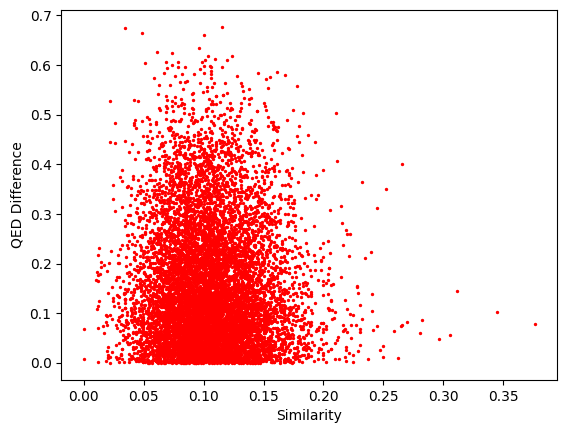

In [101]:
pred_g = plt.scatter(mfp_m, qed, color='red', s = 2)
plt.xlabel('Similarity')
plt.ylabel('QED Difference')

Text(0, 0.5, 'PlogP Difference')

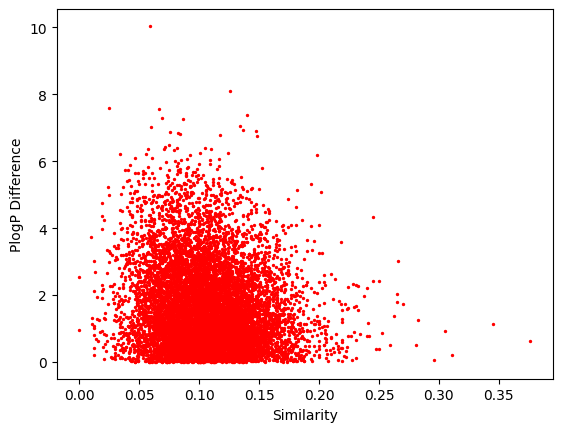

In [107]:
pred_g = plt.scatter(mfp_m, plogp, color='red', s = 2)
plt.xlabel('Similarity')
plt.ylabel('PlogP Difference')

Text(0, 0.5, 'SAS Difference')

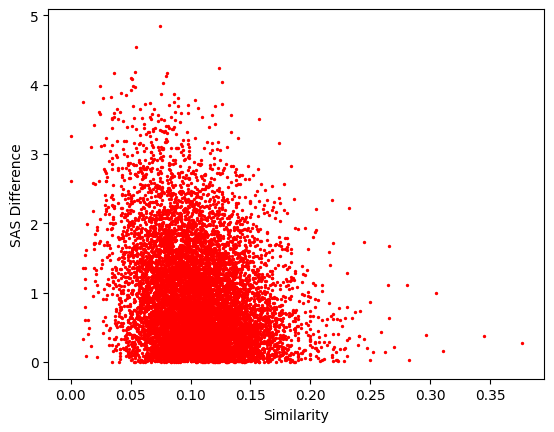

In [108]:
pred_g = plt.scatter(mfp_m, SAS, color='red', s = 2)
plt.xlabel('Similarity')
plt.ylabel('SAS Difference')

In [6]:
s1 = 'O=C1O[C@H](CO)[C@@H](O)[C@H]1O'
s2 = 'O=C1O[C@H](CO)[C@@H](O)[C@H](O)[C@H]1O'

m1 = Chem.MolFromSmiles(s1)
m2 = Chem.MolFromSmiles(s2)
fpg_s = rdFingerprintGenerator.GetMorganGenerator(fpSize=2048, radius=3)

tsim = DataStructs.FingerprintSimilarity(
    fpg_s.GetFingerprint(m1), fpg_s.GetFingerprint(m2)
)

t2sim = DataStructs.FingerprintSimilarity(
    Chem.RDKFingerprint(m1), Chem.RDKFingerprint(m2)
)
print(f'sim: {tsim:.2f}')
qed_tsim = abs(QED.qed(m1) - QED.qed(m2))
print(qed_tsim)
plogp_tsim = abs(penalized_logP(m1) - penalized_logP(m2))
print(plogp_tsim)
# SAS_tsim = abs(float(df.SAS.values[a[0]]) - float(df.SAS.values[a[1]]))
# n_rings.append(abs(
#     len(Chem.GetSymmSSSR(m1)) - len(Chem.GetSymmSSSR(m2))
# ))
# n_atoms.append(abs(
#     len(m1.GetAtoms()) - len(m2.GetAtoms())
# ))
# n_bonds.append(abs(
#     len(m1.GetBonds()) - len(m2.GetBonds())
# ))


sim: 0.72
0.04312490164949445
0.489914276917919


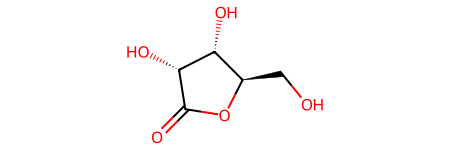

In [7]:
m1

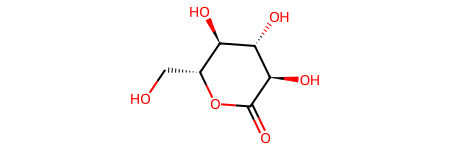

In [8]:
m2

In [13]:
# find top n smiliar mol in zinc 250k 
df = pd.read_csv('./Data/250k_rndm_zinc_drugs_clean_3.csv', sep=',')

mfp_s, mfp_m, mfp_l = [], [], [] # r = 1, 2 ,3
fpg_m = rdFingerprintGenerator.GetMorganGenerator(fpSize=2048, radius=3)
rfp = []
qed, plogp, SAS = [], [], []
n_rings, n_atoms, n_bonds = [], [], []

def get_n_rings(s):
    mol = Chem.MolFromSmiles(s)
    return len(Chem.GetSymmSSSR(mol))

ids = range(len(df.smiles))
base_mol = 'CN(C)c1cncc(O)c1N(C)C'
base_mol = Chem.MolFromSmiles(base_mol)
base_fp = fpg_m.GetFingerprint(base_mol)
base_qed = QED.qed(base_mol)

for s, q in zip(df.smiles.values[:10000], df.qed.values[:10000]):
    
    m = Chem.MolFromSmiles(s)
    tsim = DataStructs.FingerprintSimilarity(
        base_fp, fpg_s.GetFingerprint(m)
    )
    # if tsim < 0.25:
    #     continue
    mfp_m.append(tsim)
    # rfp.append(DataStructs.FingerprintSimilarity(
    #     Chem.RDKFingerprint(m1), Chem.RDKFingerprint(m2)
    # ))
    qed.append(abs(base_qed - float(q)))
    # plogp.append(abs(float(df.logP.values[a[0]]) - float(df.logP.values[a[1]])))
    # SAS.append(abs(float(df.SAS.values[a[0]]) - float(df.SAS.values[a[1]])))
    # n_rings.append(abs(
    #     len(Chem.GetSymmSSSR(m1)) - len(Chem.GetSymmSSSR(m2))
    # ))
    # n_atoms.append(abs(
    #     len(m1.GetAtoms()) - len(m2.GetAtoms())
    # ))
    # n_bonds.append(abs(
    #     len(m1.GetBonds()) - len(m2.GetBonds())
    # ))
# print(qed)
# print(plogp)
# print(SAS)
print(len(qed))
# rho = np.corrcoef([mfp_m, rfp, qed, plogp, SAS, n_rings, n_atoms, n_bonds])
rho = np.corrcoef([mfp_m, qed])
np.set_printoptions(precision=3)
print(rho)


10000
[[ 1.    -0.067]
 [-0.067  1.   ]]


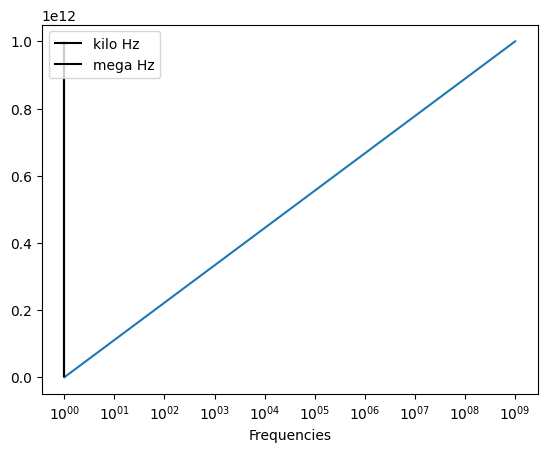

In [14]:
import numpy as np
import matplotlib.pyplot as plt
band = np.linspace(0,10**12,100)
y = band

plt.plot(band,y)
plt.xlabel("Frequencies")

plt.vlines(10**3, min(y), max(y),colors = 'black', label = 'kilo Hz')
plt.vlines(10**6, min(y), max(y),colors = 'black', label = 'mega Hz')

string_labels = []
for i in range(0,len(y),10):
    string_labels.append(r"$10^{%02d}$" % (i/10.0))

plt.xticks(np.linspace(0,10**12,10),string_labels)

plt.legend()
plt.show()